## 6.3 成對變數矩陣圖（Pair Plot）

### 1. 定義  
成對變數矩陣圖（Pair Plot）會將資料集中所有數值變數兩兩配對，建立散佈圖矩陣；對角線則展示單一變數的分布圖（如 KDE 或直方圖）。此圖表常用於探索性資料分析（EDA），便於快速觀察變數間的相關性、分布特性與群體差異。


### 2. 範例圖表與說明  

（範例圖示：Age、BMI、Blood_Sugar、Cholesterol 四變數）

**觀察與解釋**：  
- 對角線圖呈現各變數的分布（例如：年齡大多集中在 40~70 歲）  
- 非對角線為兩兩變數的散佈圖，例如 Age 與 Blood_Sugar 呈現正相關  
- 加入 hue 群組後，不同性別的分布與趨勢可明顯對比


### 3. 適用情況  
- 初步探索多個數值變數間的交互關係  
- 選擇進行建模或特徵工程的候選變數  
- 群體間變異性分析（搭配 hue）


### 4. 優缺點  
- **優點**：  
  - 一次展示所有變數的兩兩關係與單變數分布  
  - 加入 hue 可進一步呈現群體差異  
- **缺點**：  
  - 當變數數量多時，圖形變得複雜且不易解讀  
  - 資料筆數太多可能導致繪圖緩慢


### 5. 實際案例與圖表  
- **醫療領域**：探索年齡、BMI、血糖、膽固醇等健康指標間的關聯性  
- **電子商務**：分析購物頻率、停留時間、平均花費等變數之間的關聯  
- **製造領域**：檢查多項製程參數間的共變動態與潛在問題


### 6. 實作範例：醫學領域 - 健康指標之間的關聯性分析（Pair Plot）

#### 資料說明  
模擬 200 筆病患資料，包含以下欄位：  
- **Age**：年齡（整數，20～80 歲）  
- **BMI**：身體質量指數（浮點數，平均約 24）  
- **Blood_Sugar**：血糖值（根據 Age 與 BMI 模擬）  
- **Cholesterol**：膽固醇值（隨機生成）  
- **Gender**：性別（"Male" 或 "Female"）

📥 [下載資料集：patient_health_pairplot.csv](sandbox:/mnt/data/patient_health_pairplot.csv)


In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
path = '/content/drive/MyDrive/Colab Notebooks/CH6_dataset/datasets'
img_path = '/content/drive/MyDrive/Colab Notebooks/CH6_dataset/images'

Mounted at /content/drive


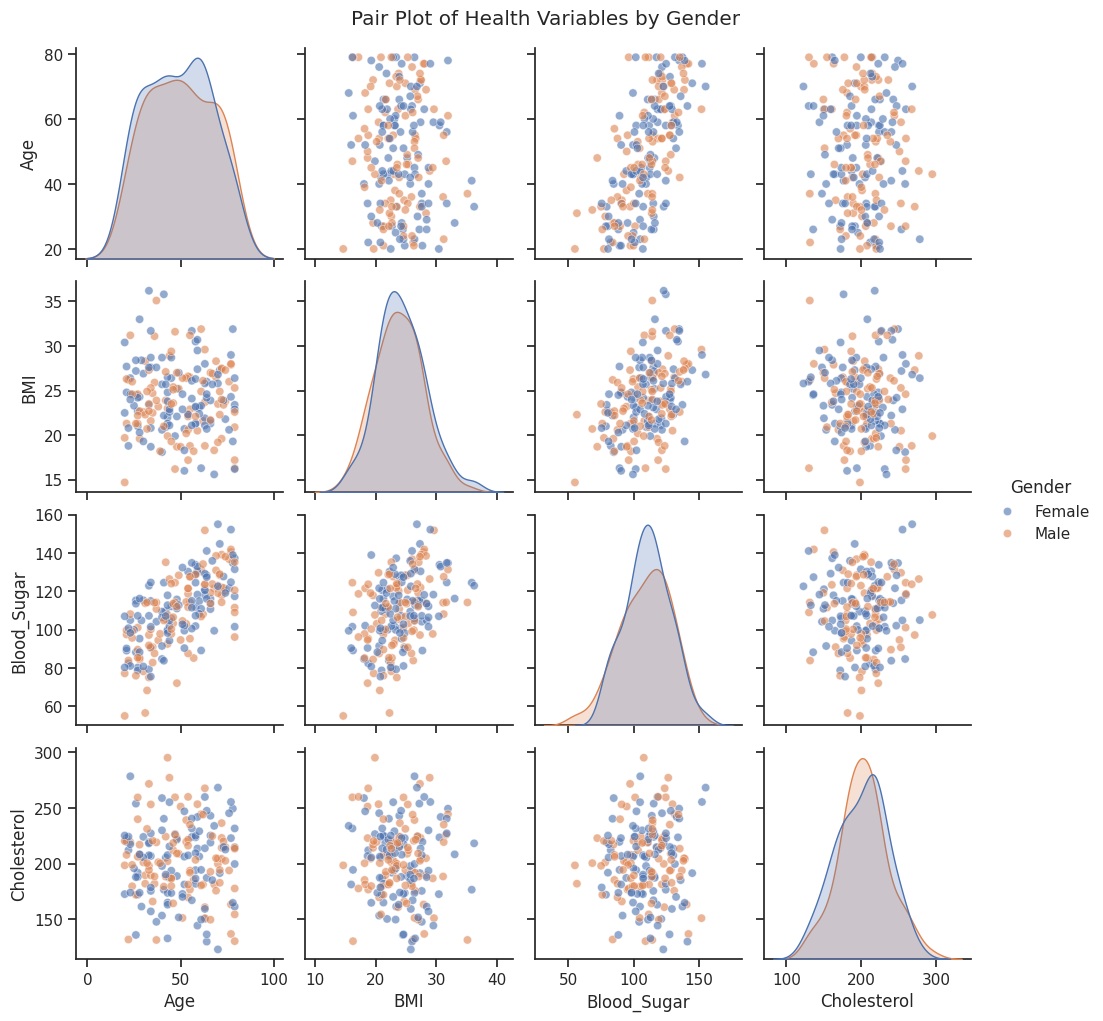

In [3]:
# 匯入必要套件
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 載入外部資料集
from pathlib import Path

data_file = "health_pairplot_data.csv"

df = pd.read_csv(path+"/"+data_file)

# 設定 seaborn 畫圖樣式
sns.set(style="ticks")

# 使用 pairplot 繪製成對變數矩陣圖
# hue：以性別分組著色；diag_kind：對角線繪製 KDE 曲線
# plot_kws：設定圖形透明度等繪圖參數
sns.pairplot(
    data=df,
    hue="Gender",              # 依據性別著色
    diag_kind="kde",           # 對角線使用 KDE 分布圖
    plot_kws={"alpha": 0.6},   # 非對角線的透明度
    corner=False               # 顯示完整矩陣（包含上三角與下三角）
)

# 加入主標題
plt.suptitle("Pair Plot of Health Variables by Gender", y=1.02)

# 顯示圖表
plt.show()


### Try it!：6. 實作範例：醫學領域 - 健康指標之間的關聯性分析（Pair Plot）
完整矩陣的上三角與下三角是重複的，改用 corner 模式讓圖更精簡。

**程式要求**
1. 讀取 `datasets/health_pairplot_data.csv`。
2. 使用 `sns.pairplot` 繪製 `Age`、`BMI`、`Blood_Sugar`、`Cholesterol` 的矩陣圖，`hue='Gender'`。
3. 設定 `corner=True` 只顯示下三角，並加上主標題。

#### 📌 補充參數與設定說明

| 參數         | 說明                                        | 建議範例值                  |
|--------------|---------------------------------------------|-----------------------------|
| `hue`        | 群組著色分類變數                            | `"Gender"`                  |
| `diag_kind`  | 對角線圖形樣式：直方圖 `"hist"` 或 KDE `"kde"` | `"kde"`                     |
| `plot_kws`   | 控制非對角散佈圖參數（例如 `alpha`）         | `{"alpha": 0.6}`            |
| `corner`     | 是否僅顯示下三角矩陣                         | `True`、`False`             |


#### 📝 練習任務建議

1. **任務一**：將 `diag_kind` 改為 `"hist"`，比較與 KDE 對角線效果差異  
2. **任務二**：移除 `hue` 設定，觀察整體資料分布無分類的情形  
3. **任務三**：使用 `vars=["Age", "BMI"]` 僅繪製兩變數之間的關聯  
4. **任務四**：設定 `corner=True`，只呈現矩陣下三角簡化視覺負擔  
5. **任務五**：修改 `plot_kws` 中的 `alpha` 值，測試不同透明度對辨識度的影響
